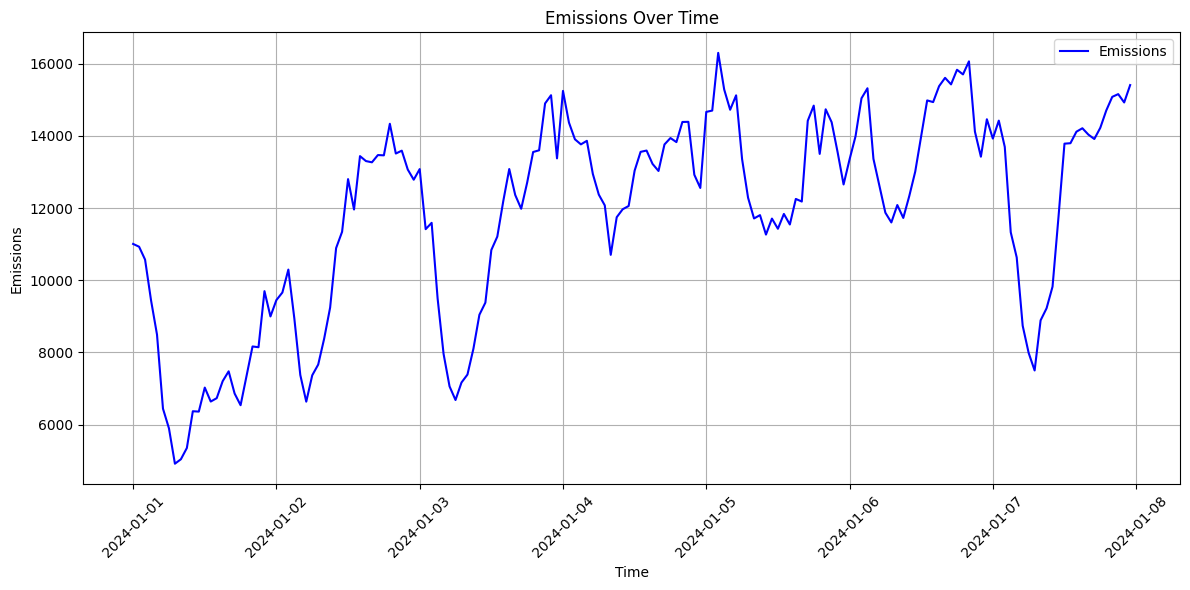

In [3]:
# Cell 1: Import required libraries
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Cell 2: Read the JSON file
# Replace 'checkpoint_hour_168.json' with the path to your JSON file
with open('/home/chad/Desktop/multi-tier-llm-routing-v2/results/2024_hourly_parallel/checkpoint_hour_168.json', 'r') as file:
    data = json.load(file)

# Cell 3: Extract emissions and timestamps
results = data['results']
emissions = [entry['emissions'] for entry in results]
timestamps = [datetime.strptime(entry['timestamp'], '%Y-%m-%dT%H:%M:%S') for entry in results]

# Cell 4: Plot the graph
plt.figure(figsize=(12, 6))
plt.plot(timestamps, emissions, linestyle='-', color='b', label='Emissions')
plt.xlabel('Time')
plt.ylabel('Emissions')
plt.title('Emissions Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cumulative Emissions Over Time for 1 year

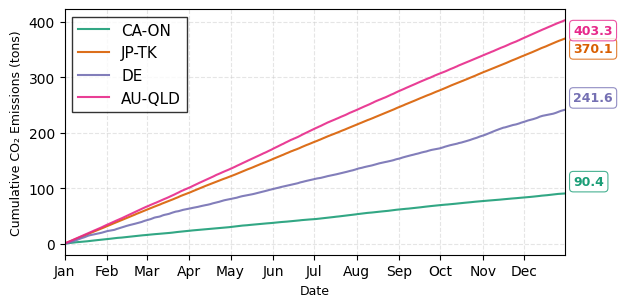

Figure saved as 'cumulative_emissions_regions_2024.png' and '.pdf'

=== Annual CO₂ Emissions Summary (metric tons) ===
  CA-ON: 90,425.0 tons CO₂ over 8760 hours
  JP-TK: 370,146.9 tons CO₂ over 8760 hours
  DE: 241,558.0 tons CO₂ over 8760 hours
  AU-QLD: 403,253.9 tons CO₂ over 8760 hours


In [2]:
# Cell 1: Import libraries
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os
import pandas as pd

# Set global font to Arial (MDPI requirement)
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'grid.color': '#cccccc',
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight'
})

# Cell 2: === USER INPUT: File paths and region names ===
file_paths = [
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/JP-TK_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/DE_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    '/home/chad/Desktop/multi-tier-llm-routing-v2/results/AU-QLD_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    #'/home/chad/Desktop/multi-tier-llm-routing-v2/results/NL_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json',
    #'/home/chad/Desktop/multi-tier-llm-routing-v2/results/US-CAL-CISO_2024_qor_sweep/qor_0.50/checkpoint_hour_8760.json'
]

region_names = ['CA-ON', 'JP-TK', 'DE', 'AU-QLD']

# Validate
if len(region_names) != len(file_paths):
    raise ValueError("Number of region names must match number of file paths!")

# Colorblind-safe palette (from ColorBrewer)
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']


# Cell 3: Create MDPI-compliant figure (16 cm x 8 cm)
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))  # cm → inches

all_timestamps = []

for i, (fp, region) in enumerate(zip(file_paths, region_names)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue
    
    with open(fp, 'r') as f:
        data = json.load(f)
    
    results = data.get('results', [])
    if not results:
        print(f"Warning: No results in {fp}")
        continue

    # Extract and convert
    try:
        timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
        emissions_g = [e['emissions'] for e in results]
    except KeyError as e:
        print(f"Warning: Missing key {e} in {fp}")
        continue

    # Convert to **metric tons**
    emissions_tons = np.array(emissions_g) / 1_000_000.0
    cumulative_tons = np.cumsum(emissions_tons)

    # Plot
    ax.plot(timestamps, cumulative_tons,
            label=f'{region}',
            color=colors[i], alpha=0.9)

    # Annotate final value in **tons**
    total_tons = cumulative_tons[-1]
    last_time = timestamps[-1]
    ax.annotate(f'{total_tons:,.1f}',
                xy=(last_time, total_tons),
                xytext=(6, 6 if i % 2 == 0 else -10),
                textcoords='offset points',
                fontsize=9, color=colors[i], fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor=colors[i], linewidth=0.8))

    all_timestamps.extend(timestamps)

# Cell 4: Final formatting (MDPI style)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative CO₂ Emissions (tons)')
#ax.set_title('Yearly Cumulative CO₂ Emissions by Region (2024, QoR = 0.50)')

# Monthly ticks
if all_timestamps:
    min_date = min(all_timestamps)
    max_date = max(all_timestamps)
    ax.set_xlim(min_date, max_date)
    
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(month_fmt)

# Legend outside if needed
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

# Tight layout already enabled via rcParams
plt.show()

# Cell 5: Export for MDPI (high-res PNG)
fig.savefig('cumulative_emissions_regions_2024.png', dpi=300)
fig.savefig('cumulative_emissions_regions_2024.pdf')  # Vector version
print("Figure saved as 'cumulative_emissions_regions_2024.png' and '.pdf'")

# Cell 6: Print summary in tons
print("\n=== Annual CO₂ Emissions Summary (metric tons) ===")
for fp, name in zip(file_paths, region_names):
    if os.path.exists(fp):
        with open(fp, 'r') as f:
            data = json.load(f)
        total_kg = np.cumsum([e['emissions'] for e in data['results']])[-1]
        total_tons = total_kg / 1000.0
        hours = len(data['results'])
        print(f"  {name}: {total_tons:,.1f} tons CO₂ over {hours} hours")
    else:
        print(f"  {name}: FILE NOT FOUND")

## 1 region, multi QoR

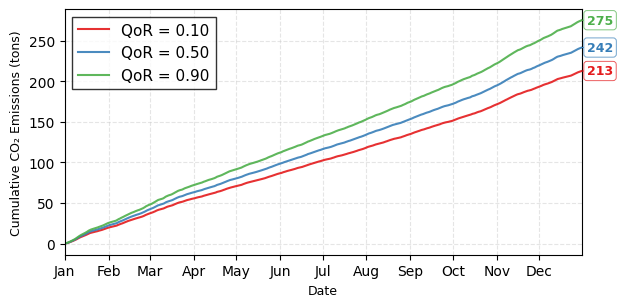


Figure saved:
  cumulative_emissions_DE_vs_qor.png
  cumulative_emissions_DE_vs_qor.pdf

=== DE: Annual CO₂ Emissions by QoR (metric tons) ===
  QoR = 0.10: 212,651.5 tons CO₂ over 8760 hours
  QoR = 0.50: 241,558.0 tons CO₂ over 8760 hours
  QoR = 0.90: 275,233.6 tons CO₂ over 8760 hours


In [3]:
# =========================================================
#  MDPI-style: Cumulative Emissions vs QoR (One Region)
# =========================================================

# Cell 1: Imports + robust font handling
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os



# ---- MDPI style rcParams ------------------------------------
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'grid.color': '#cccccc',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Cell 2: === USER INPUT: Choose ONE region and list QoR folders ===
# Example: DE region with QoR = 0.10, 0.20, 0.30, 0.40
region = 'DE'  # Change to your region: 'CA-ON', 'JP-TK', 'AU-QLD', etc.

# List of QoR values (as strings, matching folder names)
qor_values = ['0.10', '0.50', '0.90']  # Edit this list
# Base path (update this to your root directory)
base_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results'

# Construct full file paths
file_paths = [
    f"{base_path}/{region}_2024_qor_sweep/qor_{qor}/checkpoint_hour_8760.json"
    for qor in qor_values
]

# Optional: Custom labels (e.g., "QoR = 0.10")
qor_labels = [f'QoR = {float(q):.2f}' for q in qor_values]

# Validate
if len(qor_labels) != len(file_paths):
    raise ValueError("Number of QoR labels must match number of files!")

# Colorblind-safe palette (ColorBrewer Set1)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33']

# Cell 3: Create figure (16 cm × 8 cm)
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))  # cm → inches

all_timestamps = []
endpoints = []
for i, (fp, label) in enumerate(zip(file_paths, qor_labels)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue

    with open(fp, 'r') as f:
        data = json.load(f)

    results = data.get('results', [])
    if not results:
        print(f"Warning: No results in {fp}")
        continue

    # ---- Parse data ------------------------------------------------
    try:
        timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
        emissions_g = [e['emissions'] for e in results]
    except KeyError as e:
        print(f"Warning: Missing key {e} in {fp}")
        continue

    # ---- Convert to metric tons ------------------------------------
    emissions_tons = np.array(emissions_g) / 1_000_000
    cumulative_tons = np.cumsum(emissions_tons)

    # ---- Plot ------------------------------------------------------
    color = colors[i % len(colors)]
    ax.plot(timestamps, cumulative_tons,
            label=label,
            color=color, alpha=0.9)

    # ---- Annotate final total (tons) -------------------------------
    total_tons = cumulative_tons[-1]
    last_time = timestamps[-1]
    endpoints.append({
        "x": last_time,
        "y": total_tons,         # for spacing
        "y_orig": total_tons,    # true end value (for arrow anchor)
        "color": color
    })


    all_timestamps.extend(timestamps)

# Cell 4: Final formatting (MDPI)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative CO₂ Emissions (tons)')
#ax.set_title(f'Cumulative CO₂ Emissions in {region} (2024) vs QoR')

# Monthly x-ticks
if all_timestamps:
    ax.set_xlim(min(all_timestamps), max(all_timestamps))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- Non-overlapping right-side labels ---
ymin, ymax = ax.get_ylim()
if endpoints:
    # Sort by y so we can enforce a minimum vertical gap
    endpoints.sort(key=lambda d: d["y"])
    y_range = max(1e-9, ymax - ymin)        # avoid zero-div
    min_gap = 0.05 * y_range                # ~5% of axis height; tweak as needed

    # Simple "repel" to ensure spacing
    for i in range(1, len(endpoints)):
        if endpoints[i]["y"] - endpoints[i-1]["y"] < min_gap:
            endpoints[i]["y"] = endpoints[i-1]["y"] + min_gap

    # If spacing pushed the top label past the axis, extend the y-limit slightly
    if endpoints[-1]["y"] > ymax:
        ax.set_ylim(ymin, endpoints[-1]["y"] + 0.02 * y_range)

    # Put text just outside the right spine; draw a thin connector from the line end
    for d in endpoints:
        ann = ax.annotate(
            f'{d["y_orig"]:,.0f}',
            xy=(d["x"], d["y_orig"]),              # arrow anchor at true end of line
            xycoords="data",
            xytext=(1.01, d["y"]),                 # text at right margin, spaced
            textcoords=("axes fraction", "data"),  # x in axes frac, y in data
            ha="left", va="center",
            fontsize=9, fontweight="bold", color=d["color"],
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      alpha=0.7, edgecolor=d["color"], linewidth=0.7),
            arrowprops=dict(arrowstyle="-", lw=0.8, color=d["color"]),
            annotation_clip=False
        )

ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')
plt.show()

# Cell 5: Export (PNG + PDF)
fig.savefig(f'cumulative_emissions_{region}_vs_qor.png', dpi=300)
fig.savefig(f'cumulative_emissions_{region}_vs_qor.pdf')
print(f"\nFigure saved:")
print(f"  cumulative_emissions_{region}_vs_qor.png")
print(f"  cumulative_emissions_{region}_vs_qor.pdf")

# Cell 6: Summary in tons
print(f"\n=== {region}: Annual CO₂ Emissions by QoR (metric tons) ===")
for fp, label in zip(file_paths, qor_labels):
    if os.path.exists(fp):
        with open(fp, 'r') as f:
            data = json.load(f)
        total_kg = np.cumsum([e['emissions'] for e in data['results']])[-1]
        total_tons = total_kg / 1000.0
        hours = len(data['results'])
        print(f"  {label}: {total_tons:,.1f} tons CO₂ over {hours} hours")
    else:
        print(f"  {label}: FILE NOT FOUND")

## multi-region vs qor

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

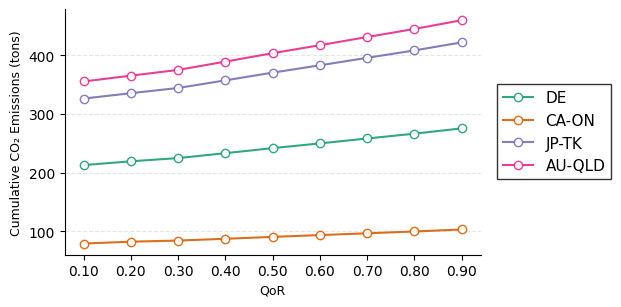

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


Figure saved:
  emissions_vs_qor_multi_region.png
  emissions_vs_qor_multi_region.pdf

=== Annual CO₂ Emissions by Region and QoR (metric tons) ===
   QoR          DE       CA-ON       JP-TK      AU-QLD
------------------------------------------------------
  0.10       212.7        79.1       325.9       355.1
  0.20       219.1        82.3       335.1       365.0
  0.30       224.6        84.2       344.0       374.7
  0.40       233.0        87.2       357.0       388.9
  0.50       241.6        90.4       370.1       403.3
  0.60       249.6        93.5       382.6       416.9
  0.70       258.0        96.6       395.4       430.8
  0.80       266.2        99.6       408.0       444.5
  0.90       275.2       103.1       421.7       459.4


In [4]:
# =========================================================
#  MDPI-style: Cumulative Emissions vs QoR (Multiple Regions)
# =========================================================

# Cell 1: Imports + robust font handling
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import numpy as np
import os

# ---- Font handling (avoid "Arial not found") ----------------
try:
    plt.rcParams.update({'font.family': 'Arial'})
except:
    plt.rcParams.update({'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'sans-serif']})

# ---- MDPI style rcParams ------------------------------------
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'grid.color': '#cccccc',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Cell 2: === USER INPUT: Regions and QoR values ===
regions = ['DE', 'CA-ON', 'JP-TK', 'AU-QLD']  # Edit regions here
qor_values = ['0.10', '0.20', '0.30', '0.40', '0.50', '0.60', '0.70', '0.80', '0.90']  # Edit QoR values here

# Base path
base_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results'

# Colorblind-safe palette (ColorBrewer Set1)
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']

# Cell 3: Extract data: {region: {qor: total_tons}}
data_by_region = {}

for region in regions:
    data_by_region[region] = {}
    for qor in qor_values:
        fp = f"{base_path}/{region}_2024_qor_sweep/qor_{qor}/checkpoint_hour_8760.json"
        if not os.path.exists(fp):
            print(f"Warning: File not found: {fp}")
            continue

        with open(fp, 'r') as f:
            js = json.load(f)

        results = js.get('results', [])
        if not results:
            print(f"Warning: No results in {fp}")
            continue

        try:
            emissions_g = [e['emissions'] for e in results]
        except KeyError:
            print(f"Warning: Missing 'emissions' in {fp}")
            continue

        total_g = np.sum(emissions_g)
        total_tons = total_g / 1_000_000.0
        data_by_region[region][float(qor)] = total_tons

# Remove regions with no data
data_by_region = {r: d for r, d in data_by_region.items() if d}

if not data_by_region:
    raise ValueError("No valid data found!")

# Cell 4: Create line + marker plot (16 cm × 8 cm)
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))  # cm → inches

# Sort QoR values for consistent x-axis
qor_sorted = sorted({q for d in data_by_region.values() for q in d.keys()})

# Plot each region
for idx, (region, qor_dict) in enumerate(data_by_region.items()):
    qors = sorted(qor_dict.keys())
    tons = [qor_dict[q] for q in qors]
    
    color = colors[idx % len(colors)]
    
    ax.plot(qors, tons,
            marker='o', markersize=6, markerfacecolor='white', markeredgecolor=color,
            color=color, linewidth=1.5, alpha=0.9, label=region)


# Cell 5: Formatting (MDPI)
ax.set_xlabel('QoR')
ax.set_ylabel('Cumulative CO₂ Emissions (tons)')
#ax.set_title('Annual CO₂ Emissions (2024) vs QoR by Region')

# X-axis: QoR ticks
ax.set_xticks(qor_sorted)
ax.set_xticklabels([f'{q:.2f}' for q in qor_sorted])

# Y-axis: comma formatting
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Grid on Y only
ax.xaxis.grid(False)
ax.yaxis.grid(True)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend: move outside the plot on the right
ax.legend(
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),  # outside plot area
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

# Cell 6: Export
fig.savefig('emissions_vs_qor_multi_region.png', dpi=300)
fig.savefig('emissions_vs_qor_multi_region.pdf')
print("\nFigure saved:")
print("  emissions_vs_qor_multi_region.png")
print("  emissions_vs_qor_multi_region.pdf")

# Cell 7: Print summary table
print("\n=== Annual CO₂ Emissions by Region and QoR (metric tons) ===")
header = f"{'QoR':>6}" + "".join([f"{r:>12}" for r in regions])
print(header)
print("-" * len(header))

for qor in qor_sorted:
    row = f"{qor:>6.2f}"
    for region in regions:
        tons = data_by_region.get(region, {}).get(qor, None)
        row += f"{tons:>12.1f}" if tons is not None else f"{'—':>12}"
    print(row)

# Energy

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

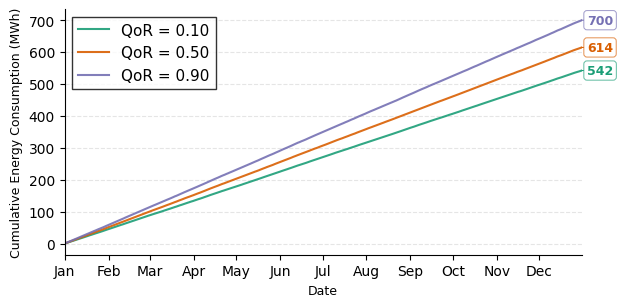

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


Figure saved:
  energy_vs_time_mwh_DE.png
  energy_vs_time_mwh_DE.pdf

=== DE: Annual Energy Consumption by QoR (MWh) ===
  QoR = 0.10: 542 MWh
  QoR = 0.50: 614 MWh
  QoR = 0.90: 700 MWh


In [5]:
# =========================================================
#  MDPI-style: Cumulative Energy (MWh) vs Time (Multiple QoR)
# =========================================================

# Cell 1: Imports + robust font handling
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os

# ---- Font handling (avoid "Arial not found") ----------------
try:
    plt.rcParams.update({'font.family': 'Arial'})
except:
    plt.rcParams.update({'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'sans-serif']})

# ---- MDPI style rcParams ------------------------------------
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'grid.color': '#cccccc',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Cell 2: === USER INPUT: Region and QoR values ===
region = 'DE'  # Change to: 'CA-ON', 'JP-TK', 'AU-QLD', etc.

# List of QoR values (as strings, matching folder names)
qor_values = ['0.10', '0.50', '0.90']  # Edit this list

# Base path
base_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results'

# Construct file paths
file_paths = [
    f"{base_path}/{region}_2024_qor_sweep/qor_{qor}/checkpoint_hour_8760.json"
    for qor in qor_values
]

# Colorblind-safe palette
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

# Cell 3: Create figure (16 cm × 8 cm)
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))  # cm → inches

all_timestamps = set()
endpoints = []


for i, (qor_str, fp) in enumerate(zip(qor_values, file_paths)):
    if not os.path.exists(fp):
        print(f"Warning: File not found: {fp}")
        continue

    with open(fp, 'r') as f:
        data = json.load(f)

    results = data.get('results', [])
    if not results:
        print(f"Warning: No results in {fp}")
        continue

    # ---- Parse timestamps and energy (kWh) ---------------------
    try:
        timestamps = [datetime.strptime(e['timestamp'], '%Y-%m-%dT%H:%M:%S') for e in results]
        # Use 'energy_kwh' if exists, else 'energy'
        if 'energy_kwh' in results[0]:
            energy_kwh = [e['energy_kwh'] for e in results]
        else:
            energy_kwh = [e['energy'] for e in results]
    except KeyError as e:
        print(f"Warning: Missing key {e} in {fp}")
        continue

    # ---- Convert to MWh and cumulative -----------------------
    energy_mwh = np.array(energy_kwh) / 1000.0
    cumulative_mwh = np.cumsum(energy_mwh)

    # ---- Plot ------------------------------------------------
    color = colors[i % len(colors)]
    label = f'QoR = {float(qor_str):.2f}'
    ax.plot(timestamps, cumulative_mwh,
            color=color, linewidth=1.5, alpha=0.9, label=label)

    # ---- Annotate final value (MWh) --------------------------
    total_mwh = cumulative_mwh[-1]
    last_time = timestamps[-1]
    endpoints.append({
        "x": last_time,
        "y": total_mwh,         # for spacing
        "y_orig": total_mwh,    # true end value (for arrow anchor)
        "color": color
        })


    all_timestamps.update(timestamps)

# Cell 4: Final formatting (MDPI)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Energy Consumption (MWh)')
#ax.set_title(f'Cumulative Energy Consumption in {region} (2024) vs QoR')

# X-axis: monthly ticks
if all_timestamps:
    min_date = min(all_timestamps)
    max_date = max(all_timestamps)
    ax.set_xlim(min_date, max_date)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- Non-overlapping right-side labels ---
ymin, ymax = ax.get_ylim()
if endpoints:
    # Sort by y so we can enforce a minimum vertical gap
    endpoints.sort(key=lambda d: d["y"])
    y_range = max(1e-9, ymax - ymin)        # avoid zero-div
    min_gap = 0.05 * y_range                # ~5% of axis height; tweak as needed

    # Simple "repel" to ensure spacing
    for i in range(1, len(endpoints)):
        if endpoints[i]["y"] - endpoints[i-1]["y"] < min_gap:
            endpoints[i]["y"] = endpoints[i-1]["y"] + min_gap

    # If spacing pushed the top label past the axis, extend the y-limit slightly
    if endpoints[-1]["y"] > ymax:
        ax.set_ylim(ymin, endpoints[-1]["y"] + 0.02 * y_range)

    # Put text just outside the right spine; draw a thin connector from the line end
    for d in endpoints:
        ann = ax.annotate(
            f'{d["y_orig"]:,.0f}',
            xy=(d["x"], d["y_orig"]),              # arrow anchor at true end of line
            xycoords="data",
            xytext=(1.01, d["y"]),                 # text at right margin, spaced
            textcoords=("axes fraction", "data"),  # x in axes frac, y in data
            ha="left", va="center",
            fontsize=9, fontweight="bold", color=d["color"],
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      alpha=0.7, edgecolor=d["color"], linewidth=0.7),
            arrowprops=dict(arrowstyle="-", lw=0.8, color=d["color"]),
            annotation_clip=False
        )

# Y-axis: comma formatting
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Grid on Y only
ax.xaxis.grid(False)
ax.yaxis.grid(True)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout()
plt.show()

# Cell 5: Export (PNG + PDF)
fig.savefig(f'energy_vs_time_mwh_{region}.png', dpi=300)
fig.savefig(f'energy_vs_time_mwh_{region}.pdf')
print(f"\nFigure saved:")
print(f"  energy_vs_time_mwh_{region}.png")
print(f"  energy_vs_time_mwh_{region}.pdf")

# Cell 6: Print summary in MWh
print(f"\n=== {region}: Annual Energy Consumption by QoR (MWh) ===")
for qor_str, fp in zip(qor_values, file_paths):
    if not os.path.exists(fp):
        print(f"  QoR = {qor_str}: FILE NOT FOUND")
        continue
    with open(fp, 'r') as f:
        data = json.load(f)
    results = data.get('results', [])
    if not results:
        continue
    energy_kwh = [e.get('energy_kwh', e.get('energy', 0)) for e in results]
    total_mwh = np.sum(energy_kwh) / 1000.0
    print(f"  QoR = {float(qor_str):.2f}: {total_mwh:,.0f} MWh")